## Import libraries

In [2]:
# Import relevant libraries 
import numpy as np
import matplotlib.pyplot as plt
from numpy import loadtxt

## Load data from data.csv file 

In [4]:
def load_data(file_name):
    df = pd.read_csv(file_name)
    X = df.iloc[:, 0].values
    y = df.iloc[:, 1].values
    print(df.head())

    return X, y

In [6]:
[X,y] = load_data("data.csv")

          X          y
0  0.374540   9.351909
1  0.950714   5.080108
2  0.731994   7.434984
3  0.598658   8.391216
4  0.156019  10.046228


## Visualise the data

In [8]:
import seaborn as sns

def vis_data(X,y):
    # Since we have x and y variable only, we use scatter plot to visualise
    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.scatter(X, y, color='skyblue')
    plt.title('Scatter Plot of X vs y')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.grid(True)

    #Histogram of the target variable
    plt.subplot(1,2,2)
    plt.hist(y, bins=10, color='purple', edgecolor='black')
    plt.title('Distribution of Target Variable')
    plt.xlabel('y')
    plt.ylabel('Frequency')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

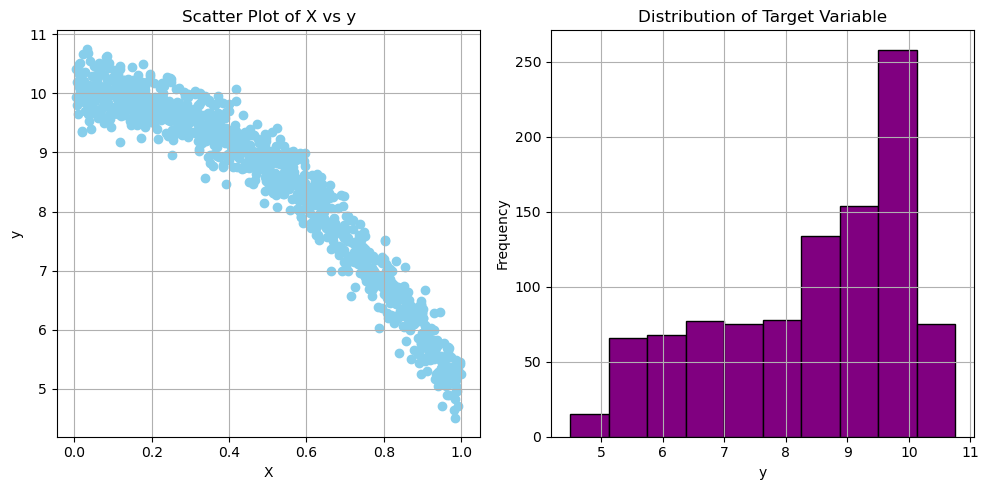

In [10]:
vis_data(X,y)

The y values are skewed to the left, indicating mean < median

## Calculate Loss

In [13]:
# y_true --> the target values.
# y_pred --> the predicted values
def loss(y_true, y_pred):    
    #Calculating loss using MSE
    loss = np.mean((y_true - y_pred) ** 2)
    return loss

In [15]:
loss(np.array([5, 2]), np.array([10, 3]))

13.0

## Calculate Gradients

In [17]:
#Input:
# X --> Input.
# y_true --> target values.
# y_pred --> predictions.
#return:
# dw --> the gradient with respect to the weights
# db --> the gradient with respect to the bias.
def gradients(X, y_true, y_pred):
    #its a 1D array
    N = len(y_true)
    
    # Gradient with respect to weights
    dw = (1 / N) * np.sum(X * (y_pred - y_true))
    
    # Gradient with respect to bias
    db = (1 / N) * np.sum(y_pred - y_true)
    
    return dw, db

### Test gradient

In [19]:
dw,db = gradients(np.array([5]),np.array([1.5]),np.array([1.1]))
print(f'dw = {dw} , db = {db}')

dw = -1.9999999999999996 , db = -0.3999999999999999


## Training

In [21]:
# X --> Input.
# y --> true/target value.

def train(X, y, learning_rate = 0.01, epochs = 1000):
    n = len(y) #number of features
    w = 0
    #w = np.zeros(m) #initialise weights as vector
    b = 0
    losses = []

    for epoch in range(epochs):
        # Calculate predictions and loss
        y_pred = np.dot(X, w) + b
        #y_pred = w * X + b
        loss_current = loss(y,y_pred)
        losses.append(loss_current)

        # Calculate gradients for both
        dw, db = gradients(X, y, y_pred)

        # Update weights and bias
        w -= learning_rate * dw
        b -= learning_rate * db

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss_current}, Weights: {w}, Bias: {b}")
    
    return w, b, losses

## Test function

In [23]:
w, b, losses = train(X, y, learning_rate = 0.1, epochs=1500)
print(f"Final Weights: {w}")
print(f"Final Bias: {b}")

Epoch 0, Loss: 72.95871157185934, Weights: 0.36921735429099384, Bias: 0.8401616834980908
Epoch 100, Loss: 1.7994004188626969, Weights: -0.7828381232168061, Bias: 8.634867572207368
Epoch 200, Loss: 0.6366162732336256, Weights: -2.8665748949078425, Bias: 9.730722884281754
Epoch 300, Loss: 0.3382552538697197, Weights: -3.922091919070145, Bias: 10.285823190975506
Epoch 400, Loss: 0.26169822630682515, Weights: -4.456763046648906, Bias: 10.567008714370271
Epoch 500, Loss: 0.24205431142222925, Weights: -4.727600189130368, Bias: 10.709442969251882
Epoch 600, Loss: 0.23701384153621882, Weights: -4.864792481670452, Bias: 10.781592903283858
Epoch 700, Loss: 0.23572049767777536, Weights: -4.934287104748939, Bias: 10.818140382576294
Epoch 800, Loss: 0.23538863609066102, Weights: -4.969489538846396, Bias: 10.836653472859078
Epoch 900, Loss: 0.23530348308801358, Weights: -4.9873212977867425, Bias: 10.846031260833895
Epoch 1000, Loss: 0.23528163351535614, Weights: -4.996353958029111, Bias: 10.85078157

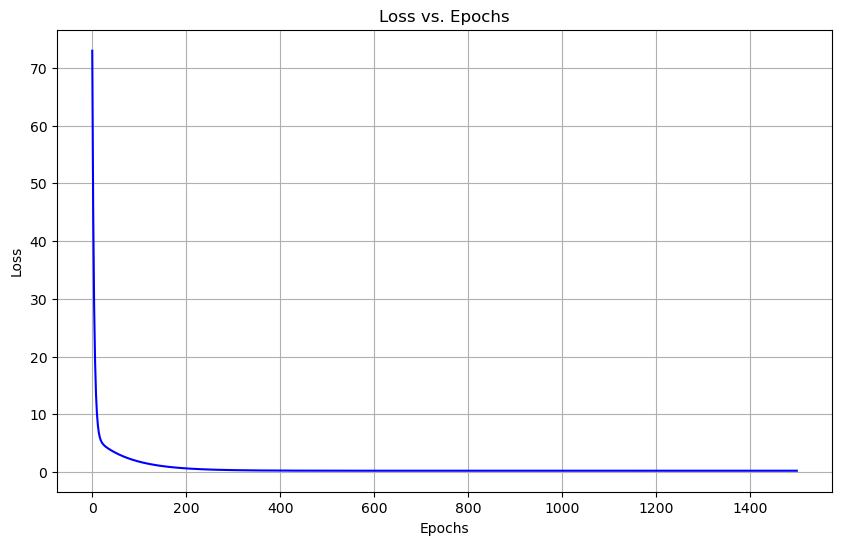

In [24]:
def plot_loss(losses): 
    plt.figure(figsize=(10, 6))
    plt.plot(losses, color='blue', label='Loss')
    plt.title('Loss vs. Epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.show()

plot_loss(losses)

### Observations
1. By Epoch 100, the loss has significantly decreased to 1.80, which shows a good improvement in prediction accuracy. It also shows the model is learning and moving in right direction
2. As the loss continue to decrease, the rate of improvement slows down. By Epoch 1400, the loss has converged to 0.23527, which is close to the minimum possible error.
3. Weights and bias stabilises, showing that the model has fully converged.
4. By Epoch 1000, the loss value does not change to a point where further training no longer significant for improvement.
5. The model successfully reduced the loss near 0.235, and achieves convergence, which proves a well-fitted model to the data.

## Prediction

In [27]:
def predict(X, w, b):
    y_pred = np.dot(X, w) + b
    #y_pred = w * X + b
    # Returning predictions.
    return y_pred

### Visualise predictions

Text(0.5, 1.0, 'Regression')

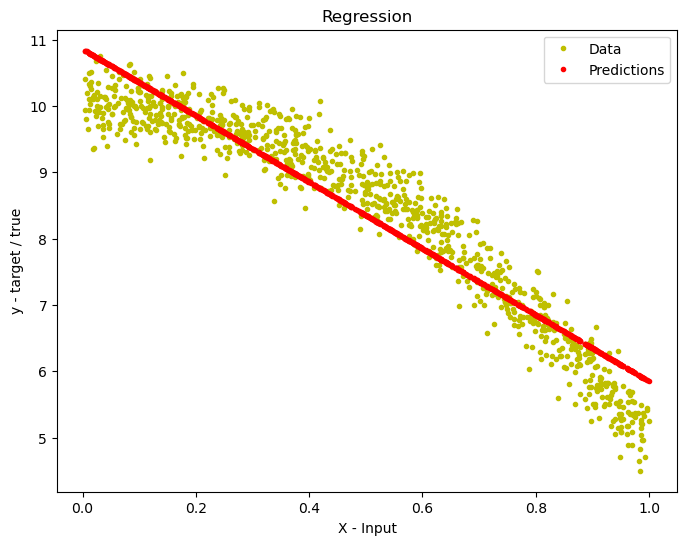

In [29]:
fig = plt.figure(figsize=(8,6))
plt.plot(X, y, 'y.')
plt.plot(X, predict(X, w, b), 'r.')  ## <- Update this function signature as needed 
plt.legend(["Data", "Predictions"])
plt.xlabel('X - Input')
plt.ylabel('y - target / true')
plt.title('Regression')

### Calculate the fit score

In [31]:
from sklearn.metrics import r2_score
y_true = y
y_pred = predict(X, w, b) ## <- Update this function signature as needed 
r2_score(y_true, y_pred)

0.9007929479384527

### Use scikit-learn to fit a linear regression model using the data from data,csv
Now you have manually implemented linear regression, do it the easier way using scikit-learn. Consider the following things:
* Loading data
* Data description
* Training and applying models
* Evaluation metrics
* Informative and comprehensive visualisations

In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [34]:
#Loading data
df = pd.read_csv("data.csv")
print(df.head())

          X          y
0  0.374540   9.351909
1  0.950714   5.080108
2  0.731994   7.434984
3  0.598658   8.391216
4  0.156019  10.046228


In [35]:
X = df[['X']]
y = df[['y']]

#Data description
print(df.shape)
print(df.describe())

(1000, 2)
                 X            y
count  1000.000000  1000.000000
mean      0.490257     8.401617
std       0.292137     1.540753
min       0.004632     4.502961
25%       0.235973     7.185142
50%       0.496807     8.818584
75%       0.744320     9.696268
max       0.999718    10.753141


In [36]:
#Training and applying models

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [37]:
#Evaluation metrics

mse = mean_squared_error(y_test, y_pred)
print(f"MSE: {mse}")

r2 = r2_score(y_test, y_pred)
print(f"r2 score: {r2}")

MSE: 0.22070158849537866
r2 score: 0.8970642211351819


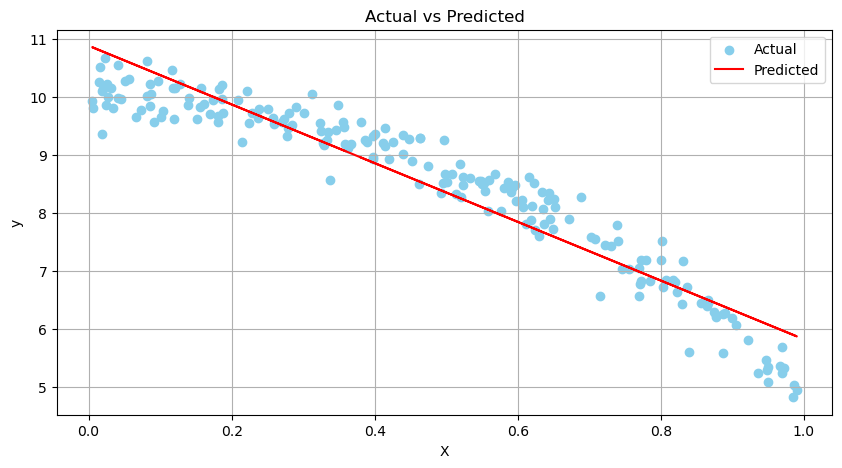

In [38]:
#Informative and comprehensive visualisations

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(X_test, y_test, color = 'skyblue', label='Actual')
plt.plot(X_test, y_pred, color = 'red', label='Predicted')

plt.title("Actual vs Predicted")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()